# UAS DATA MINING
# WALMART SALES FORECAST

# Nama : Gina Kurniawati
# NIM  : 1224160023
# Kelas: SI 24 SIM M

In [7]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport")

Library berhasil diimport


In [8]:
# ==========================================
# MEMBACA DATASET
# ==========================================

train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

print("DATA TRAIN")
print(train.shape)

print("\nDATA FEATURES")
print(features.shape)

print("\nDATA STORES")
print(stores.shape)

DATA TRAIN
(421570, 5)

DATA FEATURES
(8190, 12)

DATA STORES
(45, 3)


In [11]:
# ==========================================
# MENAMPILKAN DATA AWAL
# ==========================================

train.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False


In [7]:
# ==========================================
# INFORMASI DATA
# ==========================================

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [8]:
# ==========================================
# DESKRIPSI DATA
# ==========================================

train.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [9]:
# ==========================================
# DUPLIKAT DATA
# ==========================================

print("Jumlah Data Duplikat :")
print(train.duplicated().sum())

Jumlah Data Duplikat :
0


In [10]:
# ==========================================
# MISSING VALUE
# ==========================================

missing = train.isnull().sum()

print(missing)

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


In [11]:
# ==========================================
# MERGE DATA
# ==========================================

data = pd.merge(
    train,
    features,
    on=['Store','Date','IsHoliday'],
    how='left'
)

data = pd.merge(
    data,
    stores,
    on='Store',
    how='left'
)

print(data.shape)

(421570, 16)


In [13]:
# ==========================================
# MENAMPILKAN HASIL MERGE
# ==========================================
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [14]:
# ==========================================
# CEK MISSING VALUE SETELAH MERGE
# ==========================================
data.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [15]:
# ==========================================
# HANDLE MISSING VALUE
# ==========================================

data.fillna(0, inplace=True)

data.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [16]:
# ==========================================
# DATE TIME
# ==========================================

data['Date'] = pd.to_datetime(data['Date'])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [17]:
# ==========================================
# MEMBUAT FITUR BARU
# ==========================================

data['Year'] = data['Date'].dt.year

data['Month'] = data['Date'].dt.month

data['Week'] = data['Date'].dt.isocalendar().week

data['Day'] = data['Date'].dt.day

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,5


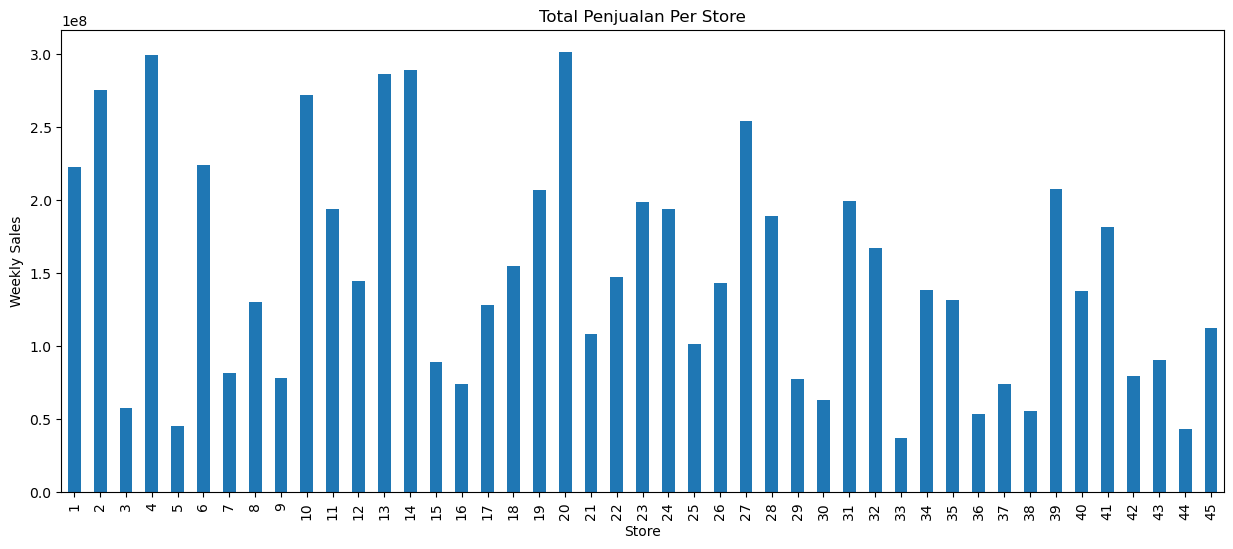

In [18]:
# ==========================================
# TOTAL PENJUALAN PER TOKO
# ==========================================

sales_store = data.groupby('Store')['Weekly_Sales'].sum()

plt.figure(figsize=(15,6))

sales_store.plot(kind='bar')

plt.title('Total Penjualan Per Store')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')

plt.show()

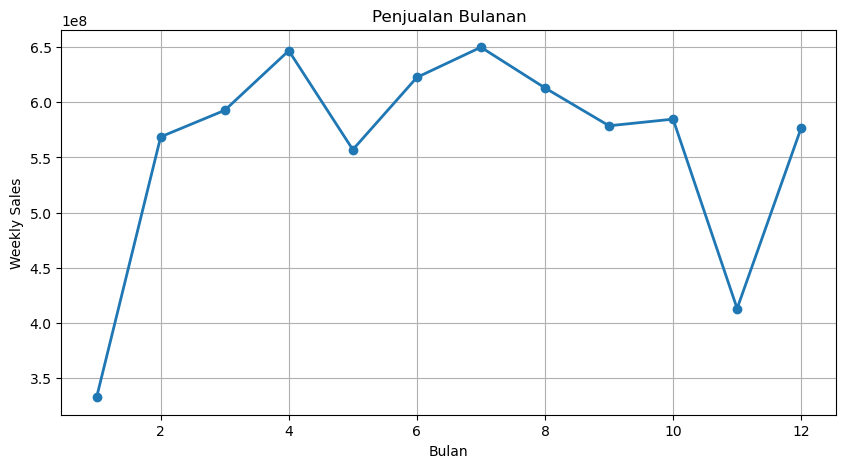

In [23]:

# ==========================================
# VISUALISASI PENJUALAN BULANAN
# ==========================================
monthly_sales = data.groupby('Month')['Weekly_Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o',
    linewidth=2
)

plt.title('Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Weekly Sales')

plt.grid()

plt.show()

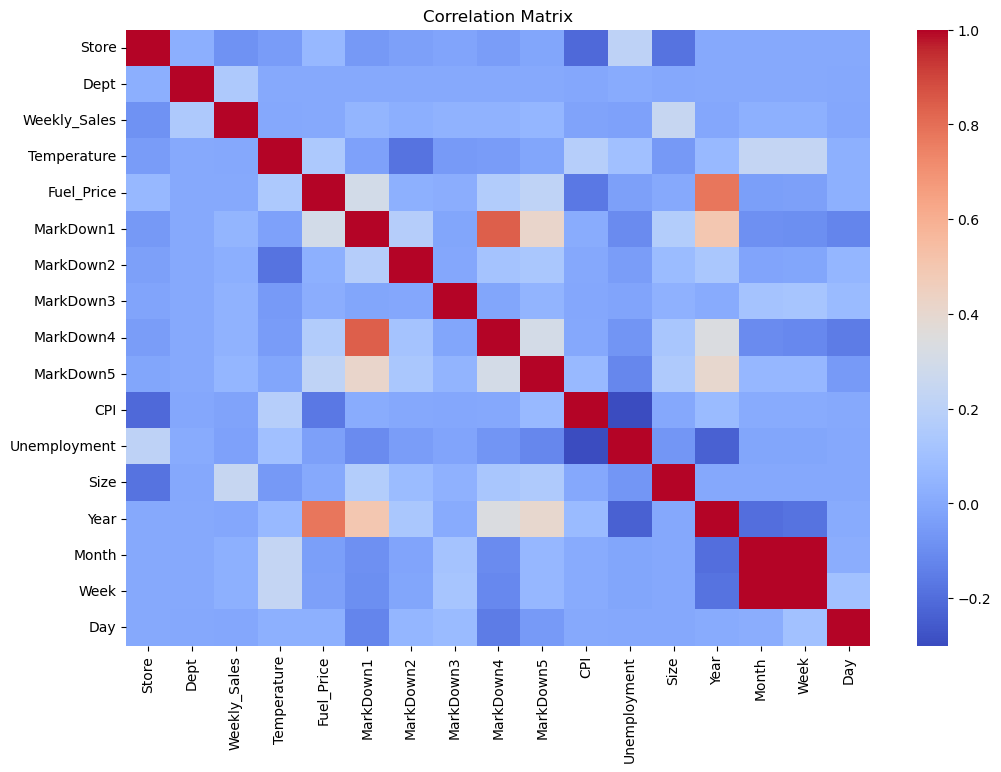

In [22]:
# ==========================================
# KORELASI DATA
# ==========================================
plt.figure(figsize=(12,8))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [24]:
# ==========================================
# ENCODING DATA KATEGORI
# ==========================================

data = pd.get_dummies(
    data,
    columns=['Type'],
    drop_first=True
)

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,Day,Type_B,Type_C
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,151315,2010,2,5,5,False,False
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,151315,2010,2,6,12,False,False
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,151315,2010,2,7,19,False,False
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,151315,2010,2,8,26,False,False
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,151315,2010,3,9,5,False,False


In [25]:
# ==========================================
# MENGUBAH DATE MENJADI NUMERIK
# ==========================================

data['Date_Number'] = data['Date'].map(
    pd.Timestamp.toordinal
)

data[['Date','Date_Number']].head()

,Date,Date_Number
0,2010-02-05,733808
1,2010-02-12,733815
2,2010-02-19,733822
3,2010-02-26,733829
4,2010-03-05,733836


In [26]:
# ==========================================
# X DAN Y
# ==========================================

X = data.drop(
    ['Weekly_Sales','Date'],
    axis=1
)

y = data['Weekly_Sales']

print(X.shape)
print(y.shape)

(421570, 20)
(421570,)


In [27]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

split = int(len(data) * 0.9)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train :", len(X_train))
print("Test :", len(X_test))

Train : 379413
Test : 42157


In [29]:
# ==========================================
# LINEAR REGRESSION
# ==========================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model berhasil dilatih")

Model berhasil dilatih


In [31]:
# ==========================================
# PREDIKSI
# ==========================================

prediksi = model.predict(X_test)

prediksi[:10]

array([18703.31603674, 18573.11881891, 19150.93340021, 19361.67191367,
       19029.43013897, 18903.15905811, 19107.60145988, 19246.98773564,
       19214.10595949, 19050.22018962])

In [33]:
# ==========================================
# RMSE
# ==========================================

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        prediksi
    )
)

print("RMSE : ", rmse)

RMSE :  18490.030031860366


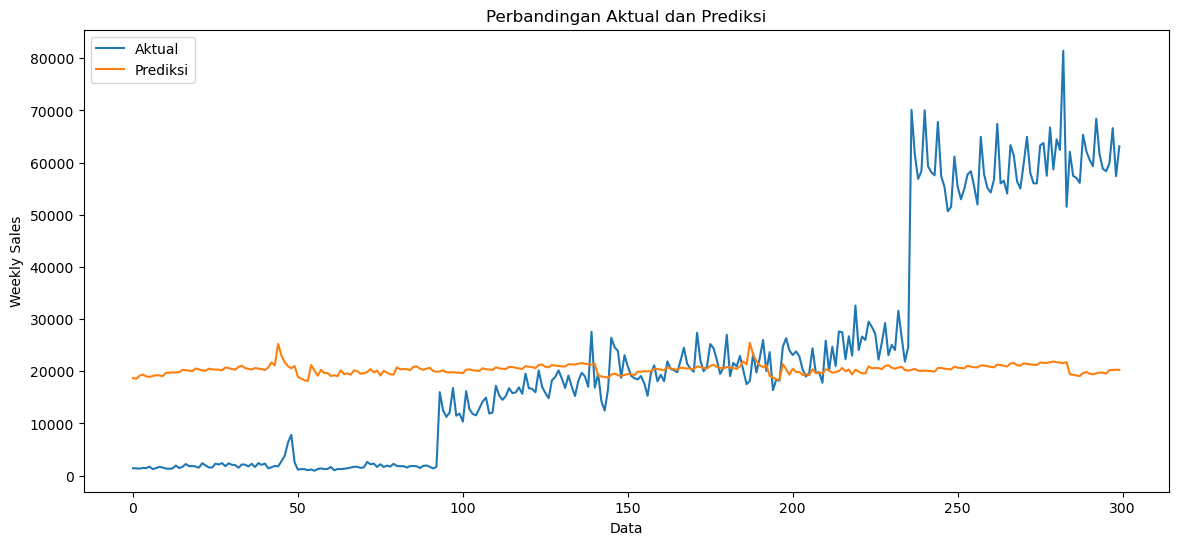

In [34]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:300],
    label='Aktual'
)

plt.plot(
    prediksi[:300],
    label='Prediksi'
)

plt.title(
    'Perbandingan Aktual dan Prediksi'
)

plt.xlabel('Data')

plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

In [35]:
tanggal_terakhir = data['Date'].max()

print("Tanggal Terakhir :")
print(tanggal_terakhir)

Tanggal Terakhir :
2012-10-26 00:00:00


In [36]:
future = X.tail(1).copy()

hasil_forecast = model.predict(future)

print(
    "Forecast Weekly Sales Berikutnya :",
    hasil_forecast[0]
)

Forecast Weekly Sales Berikutnya : 13099.149720338639


In [37]:
print("""
KESIMPULAN

1. Dataset Walmart berhasil dianalisis.
2. Data telah melalui proses cleaning dan preprocessing.
3. Model Forecasting menggunakan Linear Regression berhasil dibuat.
4. Evaluasi dilakukan menggunakan RMSE.
5. Semakin kecil RMSE maka semakin baik model.
6. Model dapat digunakan untuk memprediksi Weekly Sales Walmart.
""")


KESIMPULAN

1. Dataset Walmart berhasil dianalisis.
2. Data telah melalui proses cleaning dan preprocessing.
3. Model Forecasting menggunakan Linear Regression berhasil dibuat.
4. Evaluasi dilakukan menggunakan RMSE.
5. Semakin kecil RMSE maka semakin baik model.
6. Model dapat digunakan untuk memprediksi Weekly Sales Walmart.

